# HEPSIM Evaluation Task Solution

I use the first five standard `QG_jets_*.npz` files, so the full sample here has 500,000 jets. The workflow is straightforward: load the padded arrays, remove the zero-padded entries, rebuild constituent four-vectors from `(p_T, y, phi, pdgid)`, study the lab-frame observables, boost each jet to its center-of-mass frame, and then train quark/gluon classifiers.

At a glance, gluon jets come out with more constituents and broader radiation, while quark jets stay narrower and harder. For the classifier study, a rest-frame-only boosted-tree model reaches `AUC = 0.8642`, while a stronger lab-only feature block reaches `AUC = 0.8820`. When I combine the richer lab features with the rest-frame shape features, the score rises to `AUC = 0.8872`, and a simple averaged ensemble reaches `AUC = 0.8882`. One possible reason the rest-frame block scores a bit lower on its own is that it may be less tied to this narrow lab-frame kinematic window and therefore capture more kinematic-independent structure, which also helps explain why it works better as a complementary feature block.


In [1]:
from __future__ import annotations

import json
import os
import re
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True

RANDOM_SEED = 42
MAX_FILES = int(os.environ.get("HEPSIM_MAX_FILES", "5"))
CHUNK_SIZE = 20_000
AUTO_DOWNLOAD = os.environ.get("HEPSIM_AUTO_DOWNLOAD", "1") != "0"
MODEL_SELECTION_MAX_TRAIN = int(os.environ.get("HEPSIM_MODEL_SELECTION_MAX_TRAIN", "120000"))
MODEL_SELECTION_MAX_VAL = int(os.environ.get("HEPSIM_MODEL_SELECTION_MAX_VAL", "40000"))
DATA_DIR = Path("data")
ZENODO_API_RECORD = "https://zenodo.org/api/records/3164691"
FILE_RE = re.compile(r"QG_jets(?:_(\d+))?\.npz$")

np.set_printoptions(suppress=True, precision=5)


## (a) Data Loading and Exploration

I load the standard files with `np.load(...)`. Each file contains:

- `X`, a `numpy.ndarray` with shape `(N, M, 4)` holding the padded constituent features `(p_T, y, \phi, \mathrm{pdgid})`
- `y`, a `numpy.ndarray` with shape `(N,)` holding the jet labels (`0` for gluon, `1` for quark)

In the next cell I handle file discovery, zero-padding removal, PDG-mass lookup, four-vector reconstruction, and the lab-frame quantities needed for parts (a) and (b).


In [2]:
PDG_MASS_GEV = {
    11: 0.00051099895,
    12: 0.0,
    13: 0.1056583755,
    14: 0.0,
    16: 0.0,
    18: 0.0,
    22: 0.0,
    111: 0.1349768,
    130: 0.497611,
    211: 0.13957039,
    310: 0.497611,
    321: 0.493677,
    2112: 0.93956542,
    2212: 0.93827208,
    3122: 1.115683,
    3112: 1.197449,
    3222: 1.18937,
    3322: 1.31486,
    3312: 1.32171,
    3334: 1.67245,
}
# Tiny lookup table so pdgid -> mass stays fast inside the vectorized loops.
# Small lookup table so pdgid -> mass stays cheap inside the vectorized loops.
MASS_LOOKUP = np.zeros(5000, dtype=np.float32)
for pid, mass in PDG_MASS_GEV.items():
    if pid < len(MASS_LOOKUP):
        MASS_LOOKUP[pid] = mass
KNOWN_IDS = set(PDG_MASS_GEV)


def parse_standard_file_index(name: str) -> int | None:
    match = FILE_RE.fullmatch(name)
    if not match or "withbc" in name:
        return None
    return 0 if match.group(1) is None else int(match.group(1))


def get_standard_file_map() -> dict[int, tuple[str, str]]:
    with urllib.request.urlopen(ZENODO_API_RECORD, timeout=60) as response:
        record = json.load(response)
    file_map: dict[int, tuple[str, str]] = {}
    for entry in record["files"]:
        name = entry["key"]
        file_idx = parse_standard_file_index(name)
        if file_idx is not None:
            file_map[file_idx] = (name, entry["links"]["self"])
    return dict(sorted(file_map.items()))


def is_valid_npz(path: Path) -> bool:
    try:
        with np.load(path) as data:
            return "X" in data.files and "y" in data.files
    except Exception:
        return False


def discover_dataset_files(
    data_dir: Path | None = None,
    max_files: int = MAX_FILES,
    auto_download: bool = AUTO_DOWNLOAD,
) -> list[Path]:
    if data_dir is None:
        data_dir = DATA_DIR
    data_dir.mkdir(parents=True, exist_ok=True)

    # Keep the file selection simple: use the first valid standard shards we can find.
    # Keep the file selection simple and reproducible: just take the first valid standard shards.
    local_files = []
    for path in data_dir.glob("QG_jets*.npz"):
        file_idx = parse_standard_file_index(path.name)
        if file_idx is not None and is_valid_npz(path):
            local_files.append((file_idx, path))
    local_files.sort(key=lambda item: item[0])

    if len(local_files) < max_files and auto_download:
        file_map = get_standard_file_map()
        for file_idx, (name, url) in file_map.items():
            if len(local_files) >= max_files:
                break
            path = data_dir / name
            if path.exists() and is_valid_npz(path):
                local_files.append((file_idx, path))
                continue
            if path.exists():
                path.unlink()
            print(f"Downloading {path.name} from Zenodo ...")
            urllib.request.urlretrieve(url, path)
            if not is_valid_npz(path):
                raise RuntimeError(f"Downloaded file {path.name} is not a valid NPZ archive.")
            local_files.append((file_idx, path))
        local_files.sort(key=lambda item: item[0])

    selected = [path for _, path in local_files[:max_files]]
    if not selected:
        raise FileNotFoundError(
            "No standard QG_jets files were found. Put standard QG_jets*.npz files in ./data or enable AUTO_DOWNLOAD."
        )
    return selected


def pdg_masses_from_ids(pdgid: np.ndarray) -> np.ndarray:
    abs_id = np.abs(pdgid).astype(np.int32)
    masses = np.zeros_like(abs_id, dtype=np.float32)
    in_range = abs_id < len(MASS_LOOKUP)
    masses[in_range] = MASS_LOOKUP[abs_id[in_range]]
    return masses


def wrap_delta_phi(delta_phi: np.ndarray) -> np.ndarray:
    return (delta_phi + np.pi) % (2 * np.pi) - np.pi


def build_kinematics(batch: np.ndarray) -> dict[str, np.ndarray]:
    pt = batch[..., 0].astype(np.float32, copy=False)
    rapidity = batch[..., 1].astype(np.float32, copy=False)
    phi = batch[..., 2].astype(np.float32, copy=False)
    pdgid = batch[..., 3].astype(np.int32, copy=False)
    mask = pt > 0

    # The dataset gives (pt, y, phi, pdgid), so we rebuild the constituent 4-vectors here.
    mass = pdg_masses_from_ids(pdgid)
    mass = np.where(mask, mass, 0.0).astype(np.float32)
    mt = np.sqrt(pt * pt + mass * mass).astype(np.float32)

    px = (pt * np.cos(phi)).astype(np.float32)
    py = (pt * np.sin(phi)).astype(np.float32)
    pz = (mt * np.sinh(rapidity)).astype(np.float32)
    energy = (mt * np.cosh(rapidity)).astype(np.float32)
    eta = np.arcsinh(np.divide(pz, np.clip(pt, 1e-12, None))).astype(np.float32)

    return {
        "pt": pt,
        "rapidity": rapidity,
        "phi": phi,
        "pdgid": pdgid,
        "mask": mask,
        "mass": mass,
        "px": px,
        "py": py,
        "pz": pz,
        "energy": energy,
        "eta": eta,
    }


def process_file_lab(path: Path, chunk_size: int = CHUNK_SIZE) -> dict[str, np.ndarray]:
    with np.load(path) as data:
        X = data["X"]
        y = data["y"].astype(np.int8)

    n_jets = len(y)
    multiplicity = np.empty(n_jets, dtype=np.int32)
    leading_pt = np.empty(n_jets, dtype=np.float32)
    leading_eta = np.empty(n_jets, dtype=np.float32)
    jet_mass = np.empty(n_jets, dtype=np.float32)
    jet_width = np.empty(n_jets, dtype=np.float32)
    ptd = np.empty(n_jets, dtype=np.float32)

    quark_constituents = 0
    gluon_constituents = 0
    unknown_ids: set[int] = set()

    for start in range(0, n_jets, chunk_size):
        stop = min(start + chunk_size, n_jets)
        batch = X[start:stop]
        labels = y[start:stop]
        kin = build_kinematics(batch)

        pt = kin["pt"]
        phi = kin["phi"]
        eta = kin["eta"]
        px = kin["px"]
        py = kin["py"]
        pz = kin["pz"]
        energy = kin["energy"]
        mask = kin["mask"]
        pdgid = kin["pdgid"]

        rows = np.arange(stop - start)
        # Zero padding shows up as pt == 0, so those entries naturally drop out.
        # Zero padding shows up as pt == 0, so those entries drop out naturally here.
        counts = mask.sum(axis=1).astype(np.int32)
        multiplicity[start:stop] = counts

        quark_constituents += int(counts[labels == 1].sum())
        gluon_constituents += int(counts[labels == 0].sum())

        unique_ids = np.unique(np.abs(pdgid[mask]).astype(np.int32))
        unknown_ids.update(int(pid) for pid in unique_ids if pid not in KNOWN_IDS)

        lead_idx = pt.argmax(axis=1)
        leading_pt[start:stop] = pt[rows, lead_idx]
        leading_eta[start:stop] = eta[rows, lead_idx]

        # Sum the constituent 4-vectors to get the jet-level observables.
        jet_px = px.sum(axis=1, dtype=np.float64)
        jet_py = py.sum(axis=1, dtype=np.float64)
        jet_pz = pz.sum(axis=1, dtype=np.float64)
        jet_energy = energy.sum(axis=1, dtype=np.float64)
        jet_pt = np.sqrt(jet_px * jet_px + jet_py * jet_py)
        jet_m2 = np.clip(
            jet_energy * jet_energy - jet_px * jet_px - jet_py * jet_py - jet_pz * jet_pz,
            0.0,
            None,
        )
        jet_mass[start:stop] = np.sqrt(jet_m2).astype(np.float32)

        jet_phi = np.arctan2(jet_py, jet_px).astype(np.float32)
        jet_eta = np.arcsinh(np.divide(jet_pz, np.clip(jet_pt, 1e-12, None))).astype(np.float32)
        dphi = wrap_delta_phi(phi - jet_phi[:, None])
        deta = eta - jet_eta[:, None]
        delta_r = np.sqrt(deta * deta + dphi * dphi).astype(np.float32)

        pt_sum = pt.sum(axis=1, dtype=np.float64)
        jet_width[start:stop] = np.divide(
            (pt * delta_r).sum(axis=1, dtype=np.float64),
            np.clip(pt_sum, 1e-12, None),
        ).astype(np.float32)
        ptd[start:stop] = np.divide(
            np.sqrt((pt * pt).sum(axis=1, dtype=np.float64)),
            np.clip(pt_sum, 1e-12, None),
        ).astype(np.float32)

    return {
        "labels": y,
        "multiplicity": multiplicity,
        "leading_pt": leading_pt,
        "leading_eta": leading_eta,
        "jet_mass": jet_mass,
        "jet_width": jet_width,
        "ptd": ptd,
        "quark_constituents": quark_constituents,
        "gluon_constituents": gluon_constituents,
        "unknown_ids": sorted(unknown_ids),
    }


def run_lab_analysis(
    max_files: int = MAX_FILES,
    chunk_size: int = CHUNK_SIZE,
    auto_download: bool = AUTO_DOWNLOAD,
) -> dict:
    paths = discover_dataset_files(max_files=max_files, auto_download=auto_download)
    print("Using files:", ", ".join(path.name for path in paths))

    results = []
    for path in paths:
        print(f"Processing lab-frame quantities for {path.name} ...")
        results.append(process_file_lab(path, chunk_size=chunk_size))

    labels = np.concatenate([result["labels"] for result in results])
    multiplicity = np.concatenate([result["multiplicity"] for result in results])
    leading_pt = np.concatenate([result["leading_pt"] for result in results])
    leading_eta = np.concatenate([result["leading_eta"] for result in results])
    jet_mass = np.concatenate([result["jet_mass"] for result in results])
    jet_width = np.concatenate([result["jet_width"] for result in results])
    ptd = np.concatenate([result["ptd"] for result in results])

    quark_constituents = sum(int(result["quark_constituents"]) for result in results)
    gluon_constituents = sum(int(result["gluon_constituents"]) for result in results)
    unknown_ids = sorted({pid for result in results for pid in result["unknown_ids"]})

    return {
        "paths": paths,
        "labels": labels,
        "multiplicity": multiplicity,
        "leading_pt": leading_pt,
        "leading_eta": leading_eta,
        "jet_mass": jet_mass,
        "jet_width": jet_width,
        "ptd": ptd,
        "quark_constituents": quark_constituents,
        "gluon_constituents": gluon_constituents,
        "unknown_ids": unknown_ids,
    }


In [3]:
lab_analysis = run_lab_analysis(max_files=MAX_FILES, chunk_size=CHUNK_SIZE, auto_download=AUTO_DOWNLOAD)
display(Markdown(f"Loaded **{len(lab_analysis['labels']):,}** jets from **{len(lab_analysis['paths'])}** standard file(s)."))
print(f"Selected files: {', '.join(path.name for path in lab_analysis['paths'])}")
print(f"Unknown non-zero PDG IDs not in the lookup table: {lab_analysis['unknown_ids'] or 'None'}")


Using files: QG_jets_1.npz, QG_jets_2.npz, QG_jets_3.npz, QG_jets_4.npz, QG_jets_5.npz
Processing lab-frame quantities for QG_jets_1.npz ...


Processing lab-frame quantities for QG_jets_2.npz ...


Processing lab-frame quantities for QG_jets_3.npz ...


Processing lab-frame quantities for QG_jets_4.npz ...


Processing lab-frame quantities for QG_jets_5.npz ...


Loaded **500,000** jets from **5** standard file(s).

Selected files: QG_jets_1.npz, QG_jets_2.npz, QG_jets_3.npz, QG_jets_4.npz, QG_jets_5.npz
Unknown non-zero PDG IDs not in the lookup table: None


Total quark jets: 250,000
Total gluon jets: 250,000
Total constituents in quark jets: 8,350,222
Total constituents in gluon jets: 13,283,118


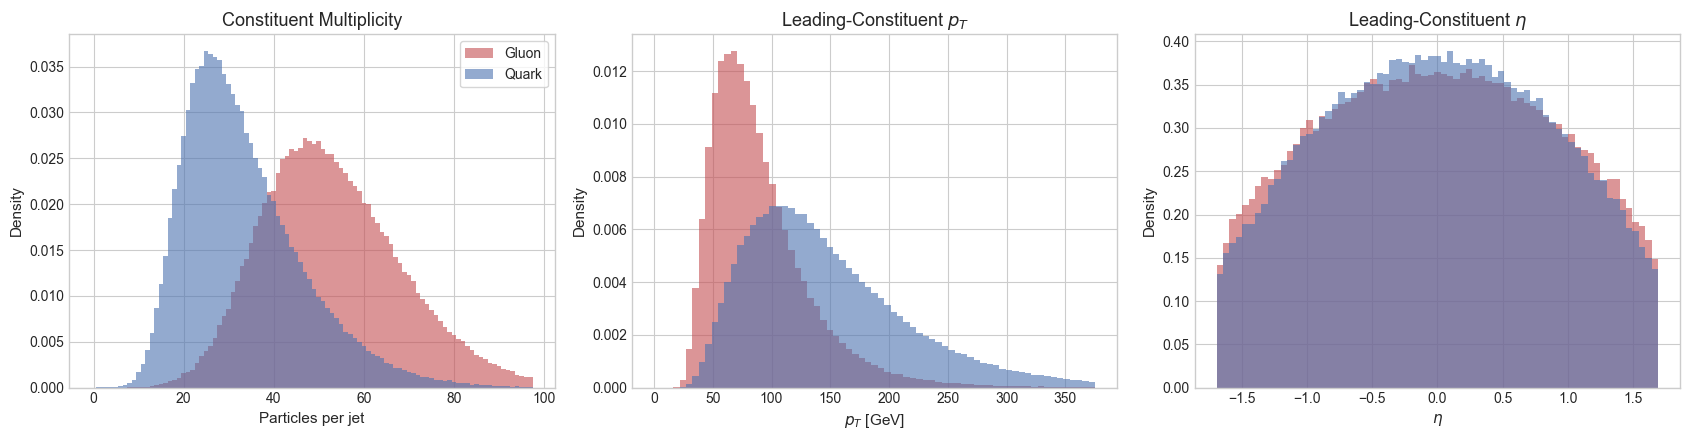

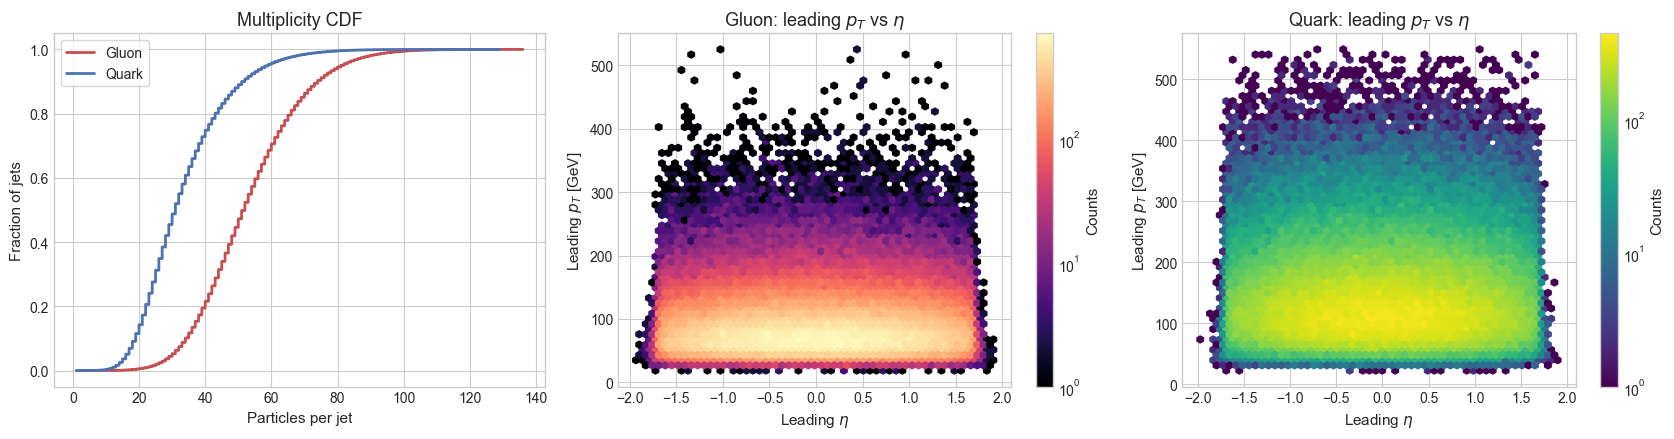

In [4]:
labels = lab_analysis["labels"]
quark_mask = labels == 1
gluon_mask = labels == 0

print(f"Total quark jets: {quark_mask.sum():,}")
print(f"Total gluon jets: {gluon_mask.sum():,}")
print(f"Total constituents in quark jets: {lab_analysis['quark_constituents']:,}")
print(f"Total constituents in gluon jets: {lab_analysis['gluon_constituents']:,}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

bins_mult = np.arange(0, np.percentile(lab_analysis["multiplicity"], 99.5) + 3) - 0.5
axes[0].hist(
    lab_analysis["multiplicity"][gluon_mask],
    bins=bins_mult,
    density=True,
    alpha=0.60,
    label="Gluon",
    color="#c44e52",
)
axes[0].hist(
    lab_analysis["multiplicity"][quark_mask],
    bins=bins_mult,
    density=True,
    alpha=0.60,
    label="Quark",
    color="#4c72b0",
)
axes[0].set_title("Constituent Multiplicity")
axes[0].set_xlabel("Particles per jet")
axes[0].set_ylabel("Density")
axes[0].legend()

bins_pt = np.linspace(0, np.percentile(lab_analysis["leading_pt"], 99.5), 70)
axes[1].hist(
    lab_analysis["leading_pt"][gluon_mask],
    bins=bins_pt,
    density=True,
    alpha=0.60,
    label="Gluon",
    color="#c44e52",
)
axes[1].hist(
    lab_analysis["leading_pt"][quark_mask],
    bins=bins_pt,
    density=True,
    alpha=0.60,
    label="Quark",
    color="#4c72b0",
)
axes[1].set_title("Leading-Constituent $p_T$")
axes[1].set_xlabel("$p_T$ [GeV]")
axes[1].set_ylabel("Density")

eta_max = np.percentile(np.abs(lab_analysis["leading_eta"]), 99.5)
bins_eta = np.linspace(-eta_max, eta_max, 70)
axes[2].hist(
    lab_analysis["leading_eta"][gluon_mask],
    bins=bins_eta,
    density=True,
    alpha=0.60,
    label="Gluon",
    color="#c44e52",
)
axes[2].hist(
    lab_analysis["leading_eta"][quark_mask],
    bins=bins_eta,
    density=True,
    alpha=0.60,
    label="Quark",
    color="#4c72b0",
)
axes[2].set_title(r"Leading-Constituent $\eta$")
axes[2].set_xlabel(r"$\eta$")
axes[2].set_ylabel("Density")

plt.tight_layout()
plt.show()

fig_extra, axes_extra = plt.subplots(1, 3, figsize=(17, 4.5))
for mask, label, color in [
    (gluon_mask, "Gluon", "#c44e52"),
    (quark_mask, "Quark", "#4c72b0"),
]:
    values = np.sort(lab_analysis["multiplicity"][mask])
    cdf = np.arange(1, len(values) + 1) / len(values)
    axes_extra[0].step(values, cdf, where="post", lw=2, color=color, label=label)
axes_extra[0].set_title("Multiplicity CDF")
axes_extra[0].set_xlabel("Particles per jet")
axes_extra[0].set_ylabel("Fraction of jets")
axes_extra[0].legend()

for ax, mask, label, cmap in [
    (axes_extra[1], gluon_mask, "Gluon", "magma"),
    (axes_extra[2], quark_mask, "Quark", "viridis"),
]:
    hb = ax.hexbin(
        lab_analysis["leading_eta"][mask],
        lab_analysis["leading_pt"][mask],
        gridsize=55,
        mincnt=1,
        bins="log",
        cmap=cmap,
    )
    ax.set_title(rf"{label}: leading $p_T$ vs $\eta$")
    ax.set_xlabel(r"Leading $\eta$")
    ax.set_ylabel(r"Leading $p_T$ [GeV]")
    fig_extra.colorbar(hb, ax=ax, label="Counts")

plt.tight_layout()
plt.show()

From these plots, the main point is clear: gluon jets have larger constituent multiplicity. The leading-particle `p_T` distribution also shifts in the expected direction, but the leading-`\eta` distribution is much less discriminating than multiplicity.


## (b) Jet Observables

I reconstruct the jet four-momentum by summing the constituent four-vectors. From that I compute jet mass, jet width,

$$
w = \frac{\sum_i p_{T,i}\,\Delta R_i}{\sum_i p_{T,i}},
$$

and transverse-momentum dispersion,

$$
p_T^D = \frac{\sqrt{\sum_i p_{T,i}^2}}{\sum_i p_{T,i}}.
$$

The dataset gives `(p_T, y, \phi, \mathrm{pdgid})`, not full constituent four-vectors, so I need a mass assignment to recover the energy. I use the PDG rest mass implied by `pdgid`, since that information is already present in the dataset. In practice that means `m_T = sqrt(p_T^2 + m^2)`, `p_z = m_T sinh(y)`, and `E = m_T cosh(y)`. A massless approximation would also work as a simplification, but using the PDG masses gives a cleaner jet-mass calculation.


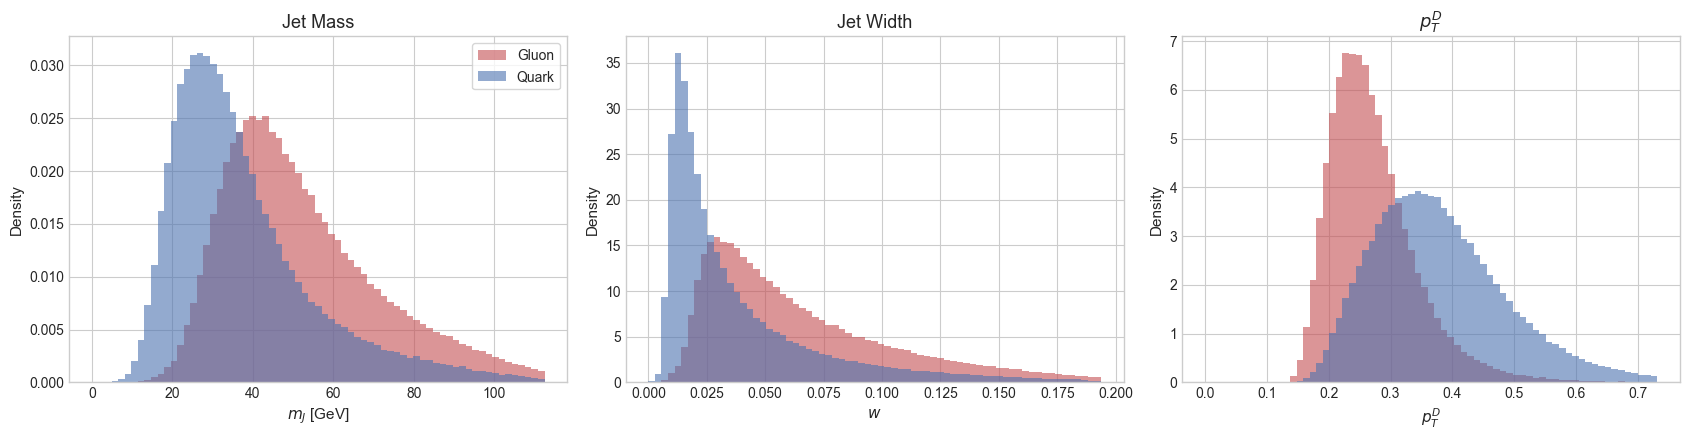

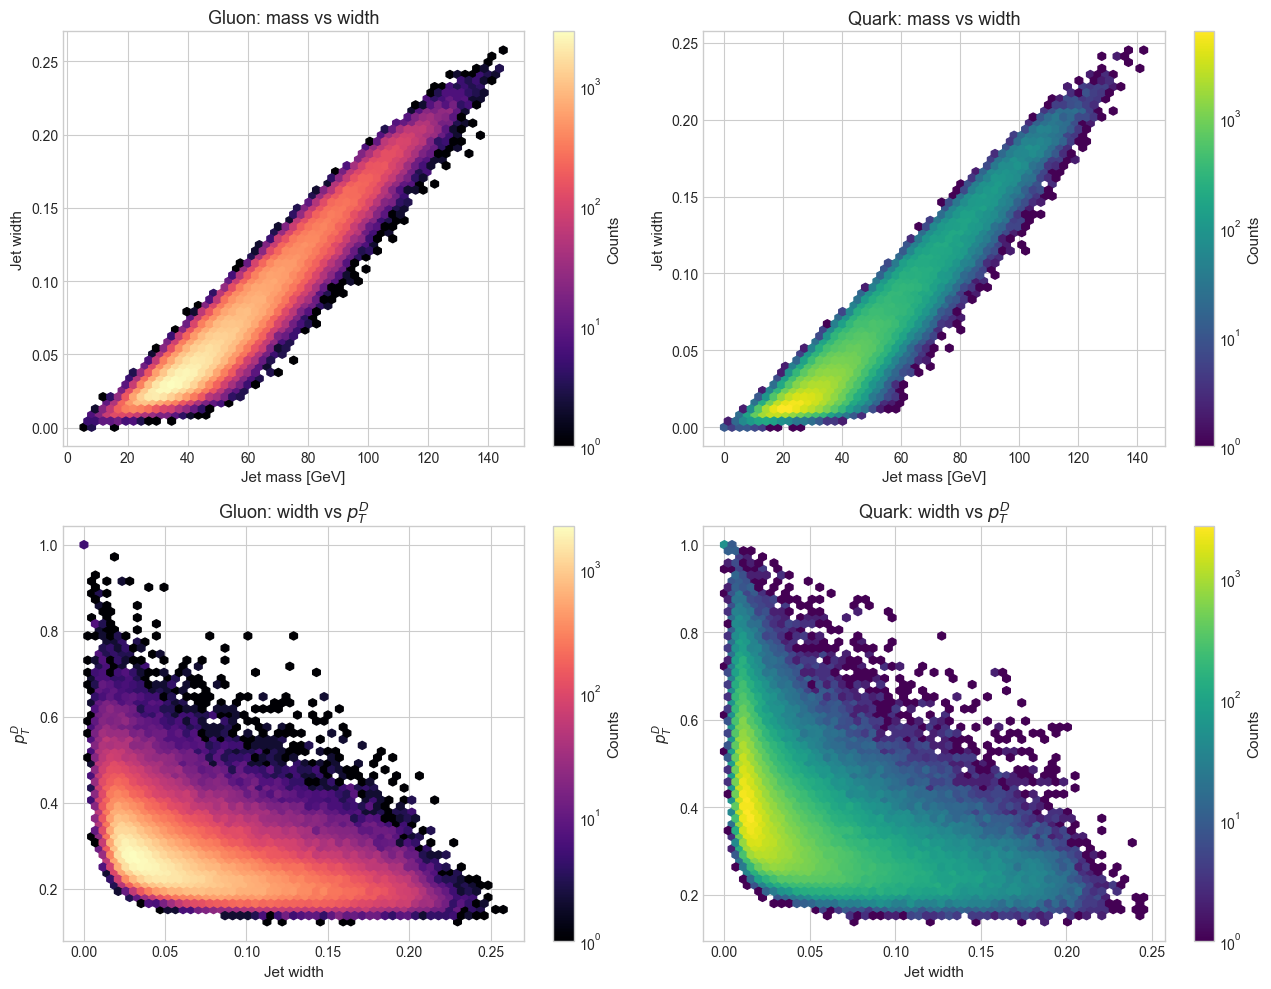

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

observable_specs = [
    ("jet_mass", "Jet Mass", "$m_J$ [GeV]"),
    ("jet_width", "Jet Width", "$w$"),
    ("ptd", "$p_T^D$", "$p_T^D$"),
]

for ax, (key, title, xlabel) in zip(axes, observable_specs):
    values = lab_analysis[key]
    upper = np.percentile(values, 99.5)
    bins = np.linspace(0, upper, 70)
    ax.hist(values[gluon_mask], bins=bins, density=True, alpha=0.60, label="Gluon", color="#c44e52")
    ax.hist(values[quark_mask], bins=bins, density=True, alpha=0.60, label="Quark", color="#4c72b0")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
axes[0].legend()
plt.tight_layout()
plt.show()

fig_maps, axes_maps = plt.subplots(2, 2, figsize=(13, 10))
for ax, mask, x_key, y_key, title, cmap in [
    (axes_maps[0, 0], gluon_mask, "jet_mass", "jet_width", "Gluon: mass vs width", "magma"),
    (axes_maps[0, 1], quark_mask, "jet_mass", "jet_width", "Quark: mass vs width", "viridis"),
    (axes_maps[1, 0], gluon_mask, "jet_width", "ptd", "Gluon: width vs $p_T^D$", "magma"),
    (axes_maps[1, 1], quark_mask, "jet_width", "ptd", "Quark: width vs $p_T^D$", "viridis"),
]:
    hb = ax.hexbin(
        lab_analysis[x_key][mask],
        lab_analysis[y_key][mask],
        gridsize=55,
        mincnt=1,
        bins="log",
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel({"jet_mass": "Jet mass [GeV]", "jet_width": "Jet width"}[x_key])
    ax.set_ylabel({"jet_width": "Jet width", "ptd": "$p_T^D$"}[y_key])
    fig_maps.colorbar(hb, ax=ax, label="Counts")

plt.tight_layout()
plt.show()

These lab-frame observables line up with the usual quark/gluon picture: gluon jets are broader, while quark jets look more pencil-like. Jet width and `p_T^D` are especially useful because they track how concentrated the jet radiation is. Jet mass helps too, but it is not enough by itself.


## (c) Boost to the Jet Center-of-Mass Frame

For a jet with total four-momentum $p_J^\mu = (E_J, \vec{p}_J)$, I use the boost

$$
\vec{\beta} = \frac{\vec{p}_J}{E_J}.
$$

The next cell applies that boost to every constituent, checks that the summed three-momentum goes to zero, and builds the rest-frame features used later in the classifier study.


In [6]:
def boost_batch_to_rest_frame(
    energy: np.ndarray,
    px: np.ndarray,
    py: np.ndarray,
    pz: np.ndarray,
    jet_energy: np.ndarray,
    jet_px: np.ndarray,
    jet_py: np.ndarray,
    jet_pz: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # Boost every jet into its own COM frame in one vectorized pass.
    # Boost every jet into its own COM frame in one vectorized shot.
    beta = np.stack(
        [
            jet_px / np.clip(jet_energy, 1e-12, None),
            jet_py / np.clip(jet_energy, 1e-12, None),
            jet_pz / np.clip(jet_energy, 1e-12, None),
        ],
        axis=1,
    ).astype(np.float64)

    bx = beta[:, 0][:, None]
    by = beta[:, 1][:, None]
    bz = beta[:, 2][:, None]
    beta2 = np.sum(beta * beta, axis=1)
    gamma = 1.0 / np.sqrt(np.clip(1.0 - beta2, 1e-14, None))
    gamma2 = np.where(beta2 > 0, (gamma - 1.0) / beta2, 0.0)

    energy64 = energy.astype(np.float64)
    px64 = px.astype(np.float64)
    py64 = py.astype(np.float64)
    pz64 = pz.astype(np.float64)

    # Same Lorentz boost as usual, just written in a broadcast-friendly way.
    beta_dot_p = bx * px64 + by * py64 + bz * pz64
    factor = gamma2[:, None] * beta_dot_p - gamma[:, None] * energy64

    boosted_px = px64 + factor * bx
    boosted_py = py64 + factor * by
    boosted_pz = pz64 + factor * bz
    boosted_energy = gamma[:, None] * (energy64 - beta_dot_p)

    return (
        boosted_energy.astype(np.float32),
        boosted_px.astype(np.float32),
        boosted_py.astype(np.float32),
        boosted_pz.astype(np.float32),
        beta.astype(np.float32),
    )


def topk_desc(values: np.ndarray, k: int) -> np.ndarray:
    width = values.shape[1]
    k = min(k, width)
    if k == width:
        result = np.sort(values, axis=1)[:, ::-1]
    else:
        result = np.partition(values, width - k, axis=1)[:, -k:]
        result = np.sort(result, axis=1)[:, ::-1]
    if k == 3:
        return result
    padded = np.zeros((values.shape[0], 3), dtype=values.dtype)
    padded[:, :k] = result
    return padded


def find_first_examples(
    labels: np.ndarray,
    mask: np.ndarray,
    energy: np.ndarray,
    px: np.ndarray,
    py: np.ndarray,
    pz: np.ndarray,
    multiplicity: np.ndarray,
    examples: dict[str, dict],
) -> None:
    for label_value, label_name in [(1, "quark"), (0, "gluon")]:
        if label_name in examples:
            continue
        matches = np.flatnonzero(labels == label_value)
        if matches.size == 0:
            continue
        idx = int(matches[0])
        valid = mask[idx]
        examples[label_name] = {
            "energy": energy[idx, valid].copy(),
            "px": px[idx, valid].copy(),
            "py": py[idx, valid].copy(),
            "pz": pz[idx, valid].copy(),
            "multiplicity": int(multiplicity[idx]),
        }


def process_file_rest(path: Path, chunk_size: int = CHUNK_SIZE) -> dict[str, np.ndarray]:
    with np.load(path) as data:
        X = data["X"]
        y = data["y"].astype(np.int8)

    n_jets = len(y)
    multiplicity = np.empty(n_jets, dtype=np.int32)
    jet_mass = np.empty(n_jets, dtype=np.float32)
    rest_dispersion = np.empty(n_jets, dtype=np.float32)
    rest_sphericity = np.empty(n_jets, dtype=np.float32)
    rest_aplanarity = np.empty(n_jets, dtype=np.float32)
    rest_planarity = np.empty(n_jets, dtype=np.float32)
    rest_C = np.empty(n_jets, dtype=np.float32)
    rest_D = np.empty(n_jets, dtype=np.float32)
    rest_top1_frac = np.empty(n_jets, dtype=np.float32)
    rest_top2_frac = np.empty(n_jets, dtype=np.float32)
    rest_top3_frac = np.empty(n_jets, dtype=np.float32)
    rest_opening_top2 = np.empty(n_jets, dtype=np.float32)
    rest_residual = np.empty(n_jets, dtype=np.float32)
    examples: dict[str, dict] = {}

    for start in range(0, n_jets, chunk_size):
        stop = min(start + chunk_size, n_jets)
        batch = X[start:stop]
        labels = y[start:stop]
        kin = build_kinematics(batch)

        pt = kin["pt"]
        px = kin["px"]
        py = kin["py"]
        pz = kin["pz"]
        energy = kin["energy"]
        mask = kin["mask"]
        counts = mask.sum(axis=1).astype(np.int32)
        multiplicity[start:stop] = counts
        rows = np.arange(stop - start)

        jet_px = px.sum(axis=1, dtype=np.float64)
        jet_py = py.sum(axis=1, dtype=np.float64)
        jet_pz = pz.sum(axis=1, dtype=np.float64)
        jet_energy = energy.sum(axis=1, dtype=np.float64)
        jet_m2 = np.clip(
            jet_energy * jet_energy - jet_px * jet_px - jet_py * jet_py - jet_pz * jet_pz,
            0.0,
            None,
        )
        jet_mass[start:stop] = np.sqrt(jet_m2).astype(np.float32)

        boosted_energy, boosted_px, boosted_py, boosted_pz, beta = boost_batch_to_rest_frame(
            energy,
            px,
            py,
            pz,
            jet_energy,
            jet_px,
            jet_py,
            jet_pz,
        )

        rest_total_px = boosted_px.sum(axis=1, dtype=np.float64)
        rest_total_py = boosted_py.sum(axis=1, dtype=np.float64)
        rest_total_pz = boosted_pz.sum(axis=1, dtype=np.float64)
        rest_residual[start:stop] = np.sqrt(
            rest_total_px * rest_total_px
            + rest_total_py * rest_total_py
            + rest_total_pz * rest_total_pz
        ).astype(np.float32)

        momentum2 = (
            boosted_px * boosted_px
            + boosted_py * boosted_py
            + boosted_pz * boosted_pz
        ).astype(np.float32)

        rest_energy_sum = boosted_energy.sum(axis=1, dtype=np.float64)
        rest_dispersion[start:stop] = np.divide(
            np.sqrt((boosted_energy * boosted_energy).sum(axis=1, dtype=np.float64)),
            np.clip(rest_energy_sum, 1e-12, None),
        ).astype(np.float32)

        # Build the momentum tensor and use its eigenvalues for the event-shape features.
        momentum2_sum = momentum2.sum(axis=1, dtype=np.float64)
        inv = 1.0 / np.clip(momentum2_sum, 1e-12, None)
        s_xx = (boosted_px * boosted_px).sum(axis=1, dtype=np.float64) * inv
        s_yy = (boosted_py * boosted_py).sum(axis=1, dtype=np.float64) * inv
        s_zz = (boosted_pz * boosted_pz).sum(axis=1, dtype=np.float64) * inv
        s_xy = (boosted_px * boosted_py).sum(axis=1, dtype=np.float64) * inv
        s_xz = (boosted_px * boosted_pz).sum(axis=1, dtype=np.float64) * inv
        s_yz = (boosted_py * boosted_pz).sum(axis=1, dtype=np.float64) * inv

        tensor = np.stack(
            [
                s_xx, s_xy, s_xz,
                s_xy, s_yy, s_yz,
                s_xz, s_yz, s_zz,
            ],
            axis=1,
        ).reshape(-1, 3, 3)
        eigenvalues = np.linalg.eigvalsh(tensor)
        lam1 = eigenvalues[:, 2]
        lam2 = eigenvalues[:, 1]
        lam3 = eigenvalues[:, 0]

        rest_sphericity[start:stop] = (1.5 * (lam2 + lam3)).astype(np.float32)
        rest_aplanarity[start:stop] = (1.5 * lam3).astype(np.float32)
        rest_planarity[start:stop] = (lam2 - lam3).astype(np.float32)
        rest_C[start:stop] = (3.0 * (lam1 * lam2 + lam1 * lam3 + lam2 * lam3)).astype(np.float32)
        rest_D[start:stop] = (27.0 * lam1 * lam2 * lam3).astype(np.float32)

        # A few simple rest-frame energy-sharing observables.
        top3_energy = topk_desc(boosted_energy, 3)
        rest_top1_frac[start:stop] = np.divide(
            top3_energy[:, 0],
            np.clip(rest_energy_sum, 1e-12, None),
        ).astype(np.float32)
        rest_top2_frac[start:stop] = np.divide(
            top3_energy[:, 1],
            np.clip(rest_energy_sum, 1e-12, None),
        ).astype(np.float32)
        rest_top3_frac[start:stop] = np.divide(
            top3_energy[:, 2],
            np.clip(rest_energy_sum, 1e-12, None),
        ).astype(np.float32)

        top2_idx = np.argpartition(boosted_energy, boosted_energy.shape[1] - 2, axis=1)[:, -2:]
        top2_energy = boosted_energy[rows[:, None], top2_idx]
        top2_order = np.argsort(top2_energy, axis=1)[:, ::-1]
        top2_idx = np.take_along_axis(top2_idx, top2_order, axis=1)
        idx1 = top2_idx[:, 0]
        idx2 = top2_idx[:, 1]
        p1x = boosted_px[rows, idx1]
        p1y = boosted_py[rows, idx1]
        p1z = boosted_pz[rows, idx1]
        p2x = boosted_px[rows, idx2]
        p2y = boosted_py[rows, idx2]
        p2z = boosted_pz[rows, idx2]
        dot12 = p1x * p2x + p1y * p2y + p1z * p2z
        norm1 = np.sqrt(p1x * p1x + p1y * p1y + p1z * p1z)
        norm2 = np.sqrt(p2x * p2x + p2y * p2y + p2z * p2z)
        cosine = np.divide(dot12, np.clip(norm1 * norm2, 1e-12, None))
        rest_opening_top2[start:stop] = np.arccos(np.clip(cosine, -1.0, 1.0)).astype(np.float32)

        find_first_examples(
            labels,
            mask,
            boosted_energy,
            boosted_px,
            boosted_py,
            boosted_pz,
            counts,
            examples,
        )

    return {
        "labels": y,
        "multiplicity": multiplicity,
        "jet_mass": jet_mass,
        "rest_dispersion": rest_dispersion,
        "rest_sphericity": rest_sphericity,
        "rest_aplanarity": rest_aplanarity,
        "rest_planarity": rest_planarity,
        "rest_C": rest_C,
        "rest_D": rest_D,
        "rest_top1_frac": rest_top1_frac,
        "rest_top2_frac": rest_top2_frac,
        "rest_top3_frac": rest_top3_frac,
        "rest_opening_top2": rest_opening_top2,
        "rest_residual": rest_residual,
        "examples": examples,
    }


def run_rest_analysis(paths: list[Path], chunk_size: int = CHUNK_SIZE) -> dict:
    results = []
    examples: dict[str, dict] = {}
    for path in paths:
        print(f"Processing rest-frame quantities for {path.name} ...")
        result = process_file_rest(path, chunk_size=chunk_size)
        results.append(result)
        for key, value in result["examples"].items():
            examples.setdefault(key, value)

    combined = {
        "labels": np.concatenate([result["labels"] for result in results]),
        "multiplicity": np.concatenate([result["multiplicity"] for result in results]),
        "jet_mass": np.concatenate([result["jet_mass"] for result in results]),
        "rest_dispersion": np.concatenate([result["rest_dispersion"] for result in results]),
        "rest_sphericity": np.concatenate([result["rest_sphericity"] for result in results]),
        "rest_aplanarity": np.concatenate([result["rest_aplanarity"] for result in results]),
        "rest_planarity": np.concatenate([result["rest_planarity"] for result in results]),
        "rest_C": np.concatenate([result["rest_C"] for result in results]),
        "rest_D": np.concatenate([result["rest_D"] for result in results]),
        "rest_top1_frac": np.concatenate([result["rest_top1_frac"] for result in results]),
        "rest_top2_frac": np.concatenate([result["rest_top2_frac"] for result in results]),
        "rest_top3_frac": np.concatenate([result["rest_top3_frac"] for result in results]),
        "rest_opening_top2": np.concatenate([result["rest_opening_top2"] for result in results]),
        "rest_residual": np.concatenate([result["rest_residual"] for result in results]),
        "examples": examples,
    }
    return combined


In [7]:
rest_analysis = run_rest_analysis(lab_analysis["paths"], chunk_size=CHUNK_SIZE)
assert np.array_equal(rest_analysis["labels"], lab_analysis["labels"])


Processing rest-frame quantities for QG_jets_1.npz ...


Processing rest-frame quantities for QG_jets_2.npz ...


Processing rest-frame quantities for QG_jets_3.npz ...


Processing rest-frame quantities for QG_jets_4.npz ...


Processing rest-frame quantities for QG_jets_5.npz ...


Median |sum p_rest|: 2.053018e-07 GeV
95th percentile |sum p_rest|: 5.493678e-07 GeV
Maximum |sum p_rest|: 2.937186e-06 GeV


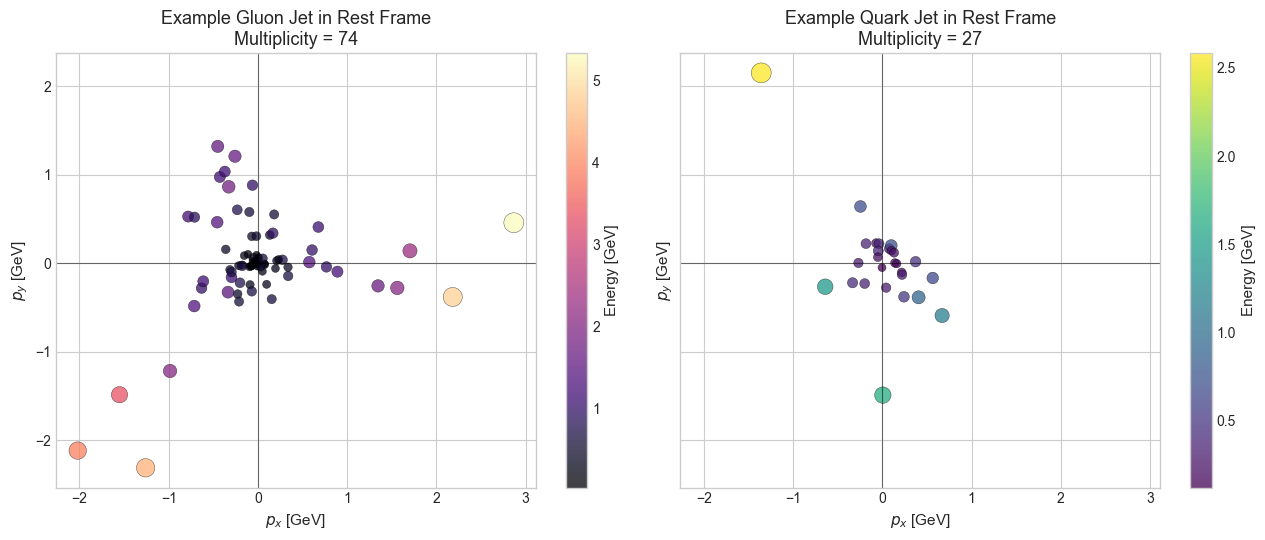

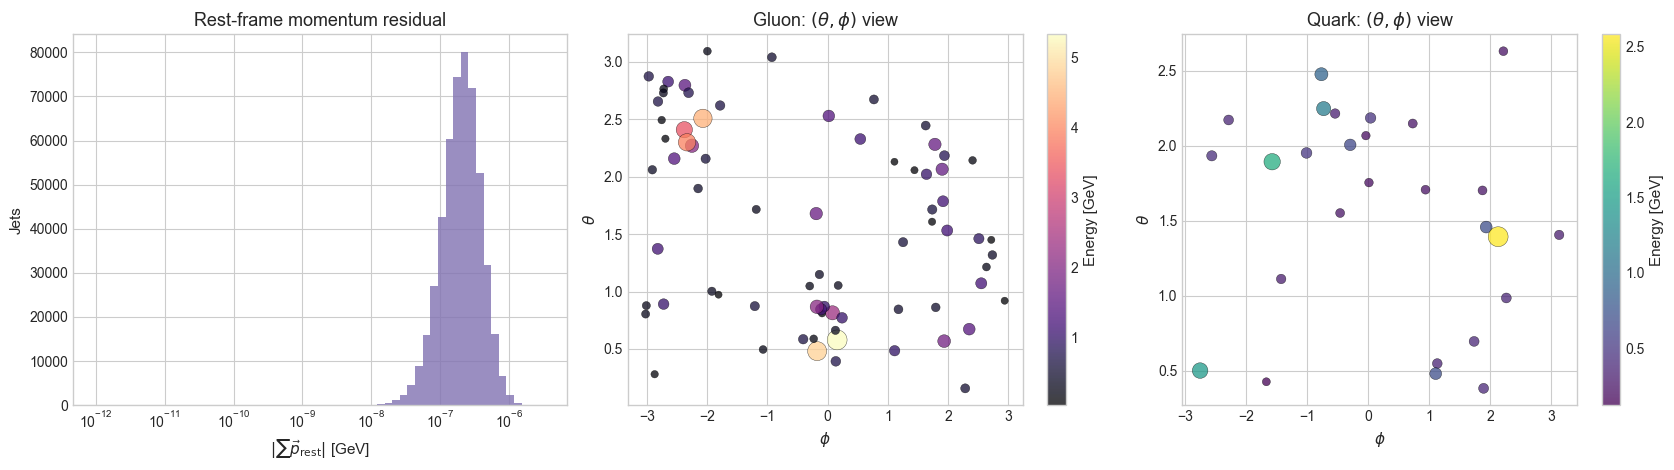

In [8]:
residual = rest_analysis["rest_residual"]
print(f"Median |sum p_rest|: {np.median(residual):.6e} GeV")
print(f"95th percentile |sum p_rest|: {np.percentile(residual, 95):.6e} GeV")
print(f"Maximum |sum p_rest|: {np.max(residual):.6e} GeV")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, key, title, cmap in [
    (axes[0], "gluon", "Example Gluon Jet in Rest Frame", "magma"),
    (axes[1], "quark", "Example Quark Jet in Rest Frame", "viridis"),
]:
    example = rest_analysis["examples"][key]
    size = 25 + 180 * example["energy"] / np.clip(example["energy"].max(), 1e-12, None)
    sc = ax.scatter(
        example["px"],
        example["py"],
        s=size,
        c=example["energy"],
        cmap=cmap,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )
    ax.axhline(0, color="black", lw=0.8, alpha=0.5)
    ax.axvline(0, color="black", lw=0.8, alpha=0.5)
    ax.set_title(f"{title}\nMultiplicity = {example['multiplicity']}")
    ax.set_xlabel("$p_x$ [GeV]")
    ax.set_ylabel("$p_y$ [GeV]")
    plt.colorbar(sc, ax=ax, label="Energy [GeV]")

plt.tight_layout()
plt.show()

fig_check, axes_check = plt.subplots(1, 3, figsize=(17, 4.8))
bins = np.logspace(
    np.log10(np.clip(residual[residual > 0].min(), 1e-12, None)),
    np.log10(residual.max() * 1.1),
    60,
)
axes_check[0].hist(residual, bins=bins, color="#8172b2", alpha=0.8)
axes_check[0].set_xscale("log")
axes_check[0].set_title("Rest-frame momentum residual")
axes_check[0].set_xlabel(r"$|\sum \vec{p}_{\rm rest}|$ [GeV]")
axes_check[0].set_ylabel("Jets")

for ax, key, title, cmap in [
    (axes_check[1], "gluon", r"Gluon: $(\theta, \phi)$ view", "magma"),
    (axes_check[2], "quark", r"Quark: $(\theta, \phi)$ view", "viridis"),
]:
    example = rest_analysis["examples"][key]
    p = np.sqrt(example["px"]**2 + example["py"]**2 + example["pz"]**2)
    theta = np.arccos(np.clip(example["pz"] / np.clip(p, 1e-12, None), -1.0, 1.0))
    phi = np.arctan2(example["py"], example["px"])
    size = 25 + 180 * example["energy"] / np.clip(example["energy"].max(), 1e-12, None)
    sc = ax.scatter(
        phi,
        theta,
        s=size,
        c=example["energy"],
        cmap=cmap,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )
    ax.set_title(title)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(r"$\theta$")
    fig_check.colorbar(sc, ax=ax, label="Energy [GeV]")

plt.tight_layout()
plt.show()

In these example rest-frame plots, the gluon jet is more spread out while the quark jet keeps more of its energy in a tighter core. The sample size here is tiny, so I treat this as a visual cross-check rather than a final conclusion. The numerical check is the important one: after the boost, the total three-momentum is essentially zero up to floating-point precision.


## (d) Quark vs. Gluon Jet Classification

For the required rest-frame classifier, I use a block of rest-frame shape and energy-sharing features: `rest_dispersion`, `rest_sphericity`, `rest_aplanarity`, `rest_planarity`, `rest_C`, `rest_D`, the top-three rest-frame energy fractions, `rest_opening_top2`, and `rest_pz_spread`, along with `multiplicity` and `jet_mass` as simple anchors.

I also build a stronger comparison model with a richer lab-frame block. That block adds standard quark/gluon observables such as `log_mult`, leading and second-constituent `p_T` fractions, Les Houches Angularity, a second radial moment, a normalized `tau_1`-like width, and a few simple energy-sharing summaries. Since the dataset includes `pdgid`, I also add lightweight particle-composition features such as charged multiplicity, charged `p_T` fraction, photon fraction, neutral-hadron fraction, and pion / kaon / baryon fractions.

The reason for this feature choice is simple:

- multiplicity and energy-sharing variables tell us how busy the jet is
- angularities and radial moments tell us how wide the radiation pattern is
- rest-frame event-shape variables tell us how the momentum is arranged once the jet is centered
- composition features use information that is already present in the dataset and can differ between quark and gluon jets

I train a tuned `HistGradientBoosting` model on the rest-only, lab-only, and combined feature blocks. I then benchmark `Extra Trees` and an `MLP` on the combined block, and finally take a simple average of the strongest combined-model scores.


In [9]:
def choose_threshold(y_true: np.ndarray, scores: np.ndarray) -> tuple[float, float]:
    thresholds = np.linspace(0.1, 0.9, 81)
    best_threshold = 0.5
    best_score = -np.inf
    for threshold in thresholds:
        score = balanced_accuracy_score(y_true, scores >= threshold)
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)
    return best_threshold, float(best_score)


def fit_and_evaluate_model(
    model_name: str,
    estimator,
    X: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
) -> dict[str, np.ndarray | float | str]:
    start = time.perf_counter()
    estimator.fit(X[train_idx], y[train_idx])
    fit_seconds = time.perf_counter() - start

    val_scores = estimator.predict_proba(X[val_idx])[:, 1]
    test_scores = estimator.predict_proba(X[test_idx])[:, 1]
    threshold, val_bal_acc = choose_threshold(y[val_idx], val_scores)

    auc = roc_auc_score(y[test_idx], test_scores)
    fpr, tpr, roc_thresholds = roc_curve(y[test_idx], test_scores)
    y_pred = (test_scores >= threshold).astype(np.int8)
    cm = confusion_matrix(y[test_idx], y_pred)
    test_bal_acc = balanced_accuracy_score(y[test_idx], y_pred)

    return {
        "model_name": model_name,
        "model": estimator,
        "fit_seconds": float(fit_seconds),
        "threshold": threshold,
        "val_auc": float(roc_auc_score(y[val_idx], val_scores)),
        "val_balanced_accuracy": float(val_bal_acc),
        "test_scores": test_scores,
        "auc": float(auc),
        "test_balanced_accuracy": float(test_bal_acc),
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "confusion_matrix": cm,
    }


def single_feature_auc_rankings(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    train_idx: np.ndarray,
) -> list[tuple[str, float]]:
    rankings = []
    y_train = y[train_idx]
    for column, name in enumerate(feature_names):
        values = X[train_idx, column]
        if np.allclose(values, values[0]):
            score = 0.5
        else:
            auc = roc_auc_score(y_train, values)
            score = max(float(auc), 1.0 - float(auc))
        rankings.append((name, score))
    rankings.sort(key=lambda item: item[1], reverse=True)
    return rankings


def compare_auc(new_auc: float, reference_auc: float) -> str:
    delta_auc = new_auc - reference_auc
    if delta_auc > 0.005:
        return "better"
    if delta_auc < -0.005:
        return "worse"
    return "about the same"


# A couple of small lookup tables let us turn `pdgid` into composition features cheaply.
PID_CATEGORY_TABLES: dict[str, np.ndarray] = {}
for name, ids in {
    "charged": [11, 13, 211, 321, 2212, 3112, 3222, 3312, 3334],
    "photon": [22],
    "neutral_hadron": [111, 130, 310, 2112, 3122, 3322],
    "pion": [111, 211],
    "kaon": [130, 310, 321],
    "baryon": [2112, 2212, 3122, 3112, 3222, 3322, 3312, 3334],
    "lepton": [11, 12, 13, 14, 16, 18],
}.items():
    table = np.zeros(5000, dtype=np.float32)
    for pid in ids:
        if pid < len(table):
            table[pid] = 1.0
    PID_CATEGORY_TABLES[name] = table


def topk_desc_any(values: np.ndarray, k: int) -> np.ndarray:
    width = values.shape[1]
    k = min(k, width)
    result = np.partition(values, width - k, axis=1)[:, -k:]
    return np.sort(result, axis=1)[:, ::-1]


def extract_advanced_feature_bank(paths: list[Path], chunk_size: int = CHUNK_SIZE) -> tuple[dict[str, np.ndarray], np.ndarray]:
    feature_parts: dict[str, list[np.ndarray]] = {}
    label_parts: list[np.ndarray] = []

    def add_feature(name: str, values: np.ndarray) -> None:
        feature_parts.setdefault(name, []).append(values.astype(np.float32))

    for path in paths:
        with np.load(path) as data:
            X = data["X"]
            y = data["y"].astype(np.int8)

        label_parts.append(y)
        print(f"Building advanced features for {path.name} ...")

        for start in range(0, len(y), chunk_size):
            stop = min(start + chunk_size, len(y))
            batch = X[start:stop]
            kin = build_kinematics(batch)

            pt = kin["pt"]
            phi = kin["phi"]
            eta = kin["eta"]
            px = kin["px"]
            py = kin["py"]
            pz = kin["pz"]
            energy = kin["energy"]
            pdgid = kin["pdgid"]
            mask = kin["mask"]
            rows = np.arange(stop - start)
            counts = mask.sum(axis=1).astype(np.float32)
            abs_id = np.abs(pdgid).astype(np.int32)

            def lookup(name: str) -> np.ndarray:
                table = PID_CATEGORY_TABLES[name]
                out = np.zeros_like(pt, dtype=np.float32)
                valid = abs_id < len(table)
                out[valid] = table[abs_id[valid]]
                return out * mask

            charged = lookup("charged")
            photon = lookup("photon")
            neutral_hadron = lookup("neutral_hadron")
            pion = lookup("pion")
            kaon = lookup("kaon")
            baryon = lookup("baryon")
            lepton = lookup("lepton")

            jet_px = px.sum(axis=1, dtype=np.float64)
            jet_py = py.sum(axis=1, dtype=np.float64)
            jet_pz = pz.sum(axis=1, dtype=np.float64)
            jet_energy = energy.sum(axis=1, dtype=np.float64)
            jet_pt = np.sqrt(jet_px * jet_px + jet_py * jet_py)
            jet_eta = np.arcsinh(np.divide(jet_pz, np.clip(jet_pt, 1e-12, None)))
            jet_phi = np.arctan2(jet_py, jet_px)
            jet_m2 = np.clip(
                jet_energy * jet_energy - jet_px * jet_px - jet_py * jet_py - jet_pz * jet_pz,
                0.0,
                None,
            )
            jet_mass = np.sqrt(jet_m2)

            dphi = wrap_delta_phi(phi - jet_phi[:, None])
            deta = eta - jet_eta[:, None]
            delta_r = np.sqrt(deta * deta + dphi * dphi).astype(np.float32)
            pt_safe = np.where(mask, pt, 0.0)
            pt_sum = pt_safe.sum(axis=1, dtype=np.float64)
            z = pt_safe / np.clip(pt_sum[:, None], 1e-12, None)

            lead_idx = pt.argmax(axis=1)
            leading_pt = pt[rows, lead_idx]
            leading_eta = eta[rows, lead_idx]
            lead_frac = leading_pt / np.clip(jet_pt, 1e-12, None)
            second_frac = topk_desc_any(pt_safe, 2)[:, 1] / np.clip(jet_pt, 1e-12, None)

            # These are cheap but pretty strong quark/gluon features.
            jet_width = (pt_safe * delta_r).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            ptd = np.sqrt((pt_safe * pt_safe).sum(axis=1, dtype=np.float64)) / np.clip(pt_sum, 1e-12, None)
            lha = (pt_safe * np.power(delta_r / 0.4, 0.5, where=mask, out=np.zeros_like(delta_r))).sum(
                axis=1,
                dtype=np.float64,
            ) / np.clip(pt_sum, 1e-12, None)
            girth2 = (pt_safe * delta_r * delta_r).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            tau1 = (pt_safe * delta_r).sum(axis=1, dtype=np.float64) / np.clip(pt_sum * 0.4, 1e-12, None)
            pt_entropy = -(z * np.log(np.clip(z, 1e-12, None))).sum(axis=1, dtype=np.float64)
            top5_frac = topk_desc_any(pt_safe, 5).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)

            charged_mult = charged.sum(axis=1, dtype=np.float64)
            charged_mult_frac = charged_mult / np.clip(counts, 1e-12, None)
            charged_pt_frac = (pt_safe * charged).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            photon_pt_frac = (pt_safe * photon).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            neutral_hadron_pt_frac = (pt_safe * neutral_hadron).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            pion_pt_frac = (pt_safe * pion).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            kaon_pt_frac = (pt_safe * kaon).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            baryon_pt_frac = (pt_safe * baryon).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)
            lepton_pt_frac = (pt_safe * lepton).sum(axis=1, dtype=np.float64) / np.clip(pt_sum, 1e-12, None)

            add_feature("multiplicity", counts)
            add_feature("log_mult", np.log1p(counts))
            add_feature("charged_mult", charged_mult)
            add_feature("charged_mult_frac", charged_mult_frac)
            add_feature("jet_mass", jet_mass)
            add_feature("jet_width", jet_width)
            add_feature("ptd", ptd)
            add_feature("jet_pt", jet_pt)
            add_feature("jet_eta", jet_eta)
            add_feature("leading_pt", leading_pt)
            add_feature("leading_eta", leading_eta)
            add_feature("lead_frac", lead_frac)
            add_feature("second_frac", second_frac)
            add_feature("lha", lha)
            add_feature("girth2", girth2)
            add_feature("tau1", tau1)
            add_feature("pt_entropy", pt_entropy)
            add_feature("top5_frac", top5_frac)
            add_feature("charged_pt_frac", charged_pt_frac)
            add_feature("photon_pt_frac", photon_pt_frac)
            add_feature("neutral_hadron_pt_frac", neutral_hadron_pt_frac)
            add_feature("pion_pt_frac", pion_pt_frac)
            add_feature("kaon_pt_frac", kaon_pt_frac)
            add_feature("baryon_pt_frac", baryon_pt_frac)
            add_feature("lepton_pt_frac", lepton_pt_frac)

            boosted_energy, boosted_px, boosted_py, boosted_pz, _ = boost_batch_to_rest_frame(
                energy,
                px,
                py,
                pz,
                jet_energy,
                jet_px,
                jet_py,
                jet_pz,
            )

            rest_energy_sum = boosted_energy.sum(axis=1, dtype=np.float64)
            momentum2 = boosted_px * boosted_px + boosted_py * boosted_py + boosted_pz * boosted_pz
            momentum2_sum = momentum2.sum(axis=1, dtype=np.float64)
            inv = 1.0 / np.clip(momentum2_sum, 1e-12, None)

            s_xx = (boosted_px * boosted_px).sum(axis=1, dtype=np.float64) * inv
            s_yy = (boosted_py * boosted_py).sum(axis=1, dtype=np.float64) * inv
            s_zz = (boosted_pz * boosted_pz).sum(axis=1, dtype=np.float64) * inv
            s_xy = (boosted_px * boosted_py).sum(axis=1, dtype=np.float64) * inv
            s_xz = (boosted_px * boosted_pz).sum(axis=1, dtype=np.float64) * inv
            s_yz = (boosted_py * boosted_pz).sum(axis=1, dtype=np.float64) * inv
            tensor = np.stack(
                [s_xx, s_xy, s_xz, s_xy, s_yy, s_yz, s_xz, s_yz, s_zz],
                axis=1,
            ).reshape(-1, 3, 3)
            eigenvalues = np.linalg.eigvalsh(tensor)
            lam1 = eigenvalues[:, 2]
            lam2 = eigenvalues[:, 1]
            lam3 = eigenvalues[:, 0]

            rest_dispersion = np.sqrt((boosted_energy * boosted_energy).sum(axis=1, dtype=np.float64)) / np.clip(
                rest_energy_sum,
                1e-12,
                None,
            )
            rest_sphericity = 1.5 * (lam2 + lam3)
            rest_aplanarity = 1.5 * lam3
            rest_planarity = lam2 - lam3
            rest_C = 3.0 * (lam1 * lam2 + lam1 * lam3 + lam2 * lam3)
            rest_D = 27.0 * lam1 * lam2 * lam3

            top3_energy = topk_desc_any(boosted_energy, 3)
            rest_top1_frac = top3_energy[:, 0] / np.clip(rest_energy_sum, 1e-12, None)
            rest_top2_frac = top3_energy[:, 1] / np.clip(rest_energy_sum, 1e-12, None)
            rest_top3_frac = top3_energy[:, 2] / np.clip(rest_energy_sum, 1e-12, None)

            top2_idx = np.argpartition(boosted_energy, boosted_energy.shape[1] - 2, axis=1)[:, -2:]
            top2_energy = boosted_energy[rows[:, None], top2_idx]
            top2_order = np.argsort(top2_energy, axis=1)[:, ::-1]
            top2_idx = np.take_along_axis(top2_idx, top2_order, axis=1)
            idx1 = top2_idx[:, 0]
            idx2 = top2_idx[:, 1]
            p1x = boosted_px[rows, idx1]
            p1y = boosted_py[rows, idx1]
            p1z = boosted_pz[rows, idx1]
            p2x = boosted_px[rows, idx2]
            p2y = boosted_py[rows, idx2]
            p2z = boosted_pz[rows, idx2]
            dot12 = p1x * p2x + p1y * p2y + p1z * p2z
            norm1 = np.sqrt(p1x * p1x + p1y * p1y + p1z * p1z)
            norm2 = np.sqrt(p2x * p2x + p2y * p2y + p2z * p2z)
            rest_opening_top2 = np.arccos(
                np.clip(dot12 / np.clip(norm1 * norm2, 1e-12, None), -1.0, 1.0)
            )
            rest_pz_spread = np.sqrt((boosted_pz * boosted_pz).sum(axis=1, dtype=np.float64)) / np.clip(
                np.sqrt(momentum2_sum),
                1e-12,
                None,
            )

            add_feature("rest_dispersion", rest_dispersion)
            add_feature("rest_sphericity", rest_sphericity)
            add_feature("rest_aplanarity", rest_aplanarity)
            add_feature("rest_planarity", rest_planarity)
            add_feature("rest_C", rest_C)
            add_feature("rest_D", rest_D)
            add_feature("rest_top1_frac", rest_top1_frac)
            add_feature("rest_top2_frac", rest_top2_frac)
            add_feature("rest_top3_frac", rest_top3_frac)
            add_feature("rest_opening_top2", rest_opening_top2)
            add_feature("rest_pz_spread", rest_pz_spread)

    feature_arrays = {
        name: np.concatenate(parts).astype(np.float32)
        for name, parts in feature_parts.items()
    }
    labels = np.concatenate(label_parts).astype(np.int8)
    return feature_arrays, labels


def build_feature_matrix(feature_arrays: dict[str, np.ndarray], selected_names: list[str]) -> np.ndarray:
    return np.column_stack([feature_arrays[name] for name in selected_names]).astype(np.float32)


def run_classification(lab_analysis: dict, rest_analysis: dict) -> dict:
    paths = lab_analysis["paths"]
    feature_arrays, labels = extract_advanced_feature_bank(paths)

    rest_feature_names = [
        "multiplicity",
        "jet_mass",
        "rest_dispersion",
        "rest_sphericity",
        "rest_aplanarity",
        "rest_planarity",
        "rest_C",
        "rest_D",
        "rest_top1_frac",
        "rest_top2_frac",
        "rest_top3_frac",
        "rest_opening_top2",
        "rest_pz_spread",
    ]
    lab_feature_names = [
        "multiplicity",
        "charged_mult",
        "charged_mult_frac",
        "log_mult",
        "jet_mass",
        "jet_width",
        "ptd",
        "jet_pt",
        "jet_eta",
        "leading_pt",
        "leading_eta",
        "lead_frac",
        "second_frac",
        "lha",
        "girth2",
        "tau1",
        "pt_entropy",
        "top5_frac",
        "charged_pt_frac",
        "photon_pt_frac",
        "neutral_hadron_pt_frac",
        "pion_pt_frac",
        "kaon_pt_frac",
        "baryon_pt_frac",
        "lepton_pt_frac",
    ]
    combined_feature_names = list(dict.fromkeys(lab_feature_names + [
        "rest_dispersion",
        "rest_sphericity",
        "rest_aplanarity",
        "rest_planarity",
        "rest_C",
        "rest_D",
        "rest_top1_frac",
        "rest_top2_frac",
        "rest_top3_frac",
        "rest_opening_top2",
        "rest_pz_spread",
    ]))

    lab_features = build_feature_matrix(feature_arrays, lab_feature_names)
    rest_features = build_feature_matrix(feature_arrays, rest_feature_names)
    combined_features = build_feature_matrix(feature_arrays, combined_feature_names)

    indices = np.arange(len(labels))
    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=labels,
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.125,
        random_state=RANDOM_SEED,
        stratify=labels[train_val_idx],
    )

    hist_params = dict(
        learning_rate=0.035,
        max_depth=8,
        max_leaf_nodes=63,
        min_samples_leaf=35,
        max_iter=700,
        l2_regularization=0.02,
        random_state=RANDOM_SEED,
    )

    lab_metrics = fit_and_evaluate_model(
        "HistGBT lab only",
        HistGradientBoostingClassifier(**hist_params),
        lab_features,
        labels,
        train_idx,
        val_idx,
        test_idx,
    )
    rest_metrics = fit_and_evaluate_model(
        "HistGBT rest only",
        HistGradientBoostingClassifier(**hist_params),
        rest_features,
        labels,
        train_idx,
        val_idx,
        test_idx,
    )
    combined_hist_metrics = fit_and_evaluate_model(
        "HistGBT combined",
        HistGradientBoostingClassifier(**hist_params),
        combined_features,
        labels,
        train_idx,
        val_idx,
        test_idx,
    )

    extra_trees_metrics = fit_and_evaluate_model(
        "Extra Trees combined",
        ExtraTreesClassifier(
            n_estimators=500,
            max_depth=28,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_SEED,
        ),
        combined_features,
        labels,
        train_idx,
        val_idx,
        test_idx,
    )
    mlp_metrics = fit_and_evaluate_model(
        "MLP combined",
        make_pipeline(
            QuantileTransformer(
                output_distribution="normal",
                random_state=RANDOM_SEED,
                n_quantiles=2000,
            ),
            MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),
                activation="relu",
                alpha=2e-5,
                batch_size=4096,
                early_stopping=True,
                learning_rate_init=4e-4,
                max_iter=120,
                n_iter_no_change=12,
                random_state=RANDOM_SEED,
            ),
        ),
        combined_features,
        labels,
        train_idx,
        val_idx,
        test_idx,
    )

    ensemble_val_scores = np.column_stack([
        combined_hist_metrics["model"].predict_proba(combined_features[val_idx])[:, 1],
        extra_trees_metrics["model"].predict_proba(combined_features[val_idx])[:, 1],
        mlp_metrics["model"].predict_proba(combined_features[val_idx])[:, 1],
    ]).mean(axis=1)
    ensemble_test_scores = np.column_stack([
        combined_hist_metrics["test_scores"],
        extra_trees_metrics["test_scores"],
        mlp_metrics["test_scores"],
    ]).mean(axis=1)
    threshold, val_bal_acc = choose_threshold(labels[val_idx], ensemble_val_scores)
    ensemble_metrics = {
        "model_name": "Averaged ensemble",
        "model": None,
        "fit_seconds": 0.0,
        "threshold": threshold,
        "val_auc": float(roc_auc_score(labels[val_idx], ensemble_val_scores)),
        "val_balanced_accuracy": float(val_bal_acc),
        "test_scores": ensemble_test_scores,
        "auc": float(roc_auc_score(labels[test_idx], ensemble_test_scores)),
        "test_balanced_accuracy": float(
            balanced_accuracy_score(labels[test_idx], ensemble_test_scores >= threshold)
        ),
        "fpr": roc_curve(labels[test_idx], ensemble_test_scores)[0],
        "tpr": roc_curve(labels[test_idx], ensemble_test_scores)[1],
        "roc_thresholds": roc_curve(labels[test_idx], ensemble_test_scores)[2],
        "confusion_matrix": confusion_matrix(
            labels[test_idx],
            (ensemble_test_scores >= threshold).astype(np.int8),
        ),
    }

    model_results = {
        "HistGBT lab only": lab_metrics,
        "HistGBT rest only": rest_metrics,
        "HistGBT combined": combined_hist_metrics,
        "Extra Trees combined": extra_trees_metrics,
        "MLP combined": mlp_metrics,
        "Averaged ensemble": ensemble_metrics,
    }
    overall_rankings = single_feature_auc_rankings(
        combined_features,
        labels,
        combined_feature_names,
        train_idx,
    )
    rest_rankings = single_feature_auc_rankings(
        rest_features,
        labels,
        rest_feature_names,
        train_idx,
    )
    rest_specific_rankings = [
        item for item in rest_rankings
        if item[0] not in {"multiplicity", "jet_mass"}
    ]

    rest_vs_lab = compare_auc(rest_metrics["auc"], lab_metrics["auc"])
    combined_vs_lab = compare_auc(combined_hist_metrics["auc"], lab_metrics["auc"])
    best_model_name, best_model_metrics = max(
        model_results.items(),
        key=lambda item: item[1]["auc"],
    )

    summary = (
        f"Using only the rest-frame block gives AUC {rest_metrics['auc']:.4f}. "
        f"The enriched lab-only block gives AUC {lab_metrics['auc']:.4f}, so the rest-only model is {rest_vs_lab} on this dataset. "
        f"This means the rest-frame variables do not replace the stronger lab observables by themselves. "
        f"But when I add the rest-frame geometry on top of the richer lab features, the tuned HistGradientBoosting score rises to {combined_hist_metrics['auc']:.4f}, "
        f"and a simple averaged ensemble reaches {ensemble_metrics['auc']:.4f}. "
        f"So the rest-frame block is most useful here as complementary information rather than as a standalone winner. "
        f"The strongest overall single feature is `{overall_rankings[0][0]}` (score {overall_rankings[0][1]:.4f}), and the strongest genuinely rest-frame feature is "
        f"`{rest_specific_rankings[0][0]}` (score {rest_specific_rankings[0][1]:.4f})."
    )

    return {
        "labels": labels,
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
        "lab_feature_names": lab_feature_names,
        "rest_feature_names": rest_feature_names,
        "combined_feature_names": combined_feature_names,
        "lab_features": lab_features,
        "rest_features": rest_features,
        "combined_features": combined_features,
        "model_results": model_results,
        "lab_metrics": lab_metrics,
        "rest_metrics": rest_metrics,
        "combined_hist_metrics": combined_hist_metrics,
        "ensemble_metrics": ensemble_metrics,
        "overall_rankings": overall_rankings,
        "rest_rankings": rest_rankings,
        "rest_specific_rankings": rest_specific_rankings,
        "rest_vs_lab": rest_vs_lab,
        "combined_vs_lab": combined_vs_lab,
        "best_model_name": best_model_name,
        "best_model_metrics": best_model_metrics,
        "summary": summary,
    }


In [10]:
classification = run_classification(lab_analysis, rest_analysis)
display(Markdown("## Main classification result\n\n" + classification["summary"]))


Building advanced features for QG_jets_1.npz ...


Building advanced features for QG_jets_2.npz ...


Building advanced features for QG_jets_3.npz ...


Building advanced features for QG_jets_4.npz ...


Building advanced features for QG_jets_5.npz ...


## Main classification result

Using only the rest-frame block gives AUC 0.8642. The enriched lab-only block gives AUC 0.8820, so the rest-only model is worse on this dataset. This means the rest-frame variables do not replace the stronger lab observables by themselves. But when I add the rest-frame geometry on top of the richer lab features, the tuned HistGradientBoosting score rises to 0.8872, and a simple averaged ensemble reaches 0.8882. So the rest-frame block is most useful here as complementary information rather than as a standalone winner. The strongest overall single feature is `multiplicity` (score 0.8411), and the strongest genuinely rest-frame feature is `rest_dispersion` (score 0.8326).

Model comparison on the 5-file sample:
  HistGBT lab only       AUC = 0.8820 | balanced acc = 0.8028
  HistGBT rest only      AUC = 0.8642 | balanced acc = 0.7842
  HistGBT combined       AUC = 0.8872 | balanced acc = 0.8094
  Extra Trees combined   AUC = 0.8823 | balanced acc = 0.8042
  MLP combined           AUC = 0.8873 | balanced acc = 0.8088
  Averaged ensemble      AUC = 0.8882 | balanced acc = 0.8105

Rest-only compared with lab-only: worse
Combined compared with lab-only: better
Best overall model: Averaged ensemble (AUC = 0.8882)
Strongest overall single feature: multiplicity (score = 0.8411)
Strongest genuinely rest-frame feature: rest_dispersion (score = 0.8326)


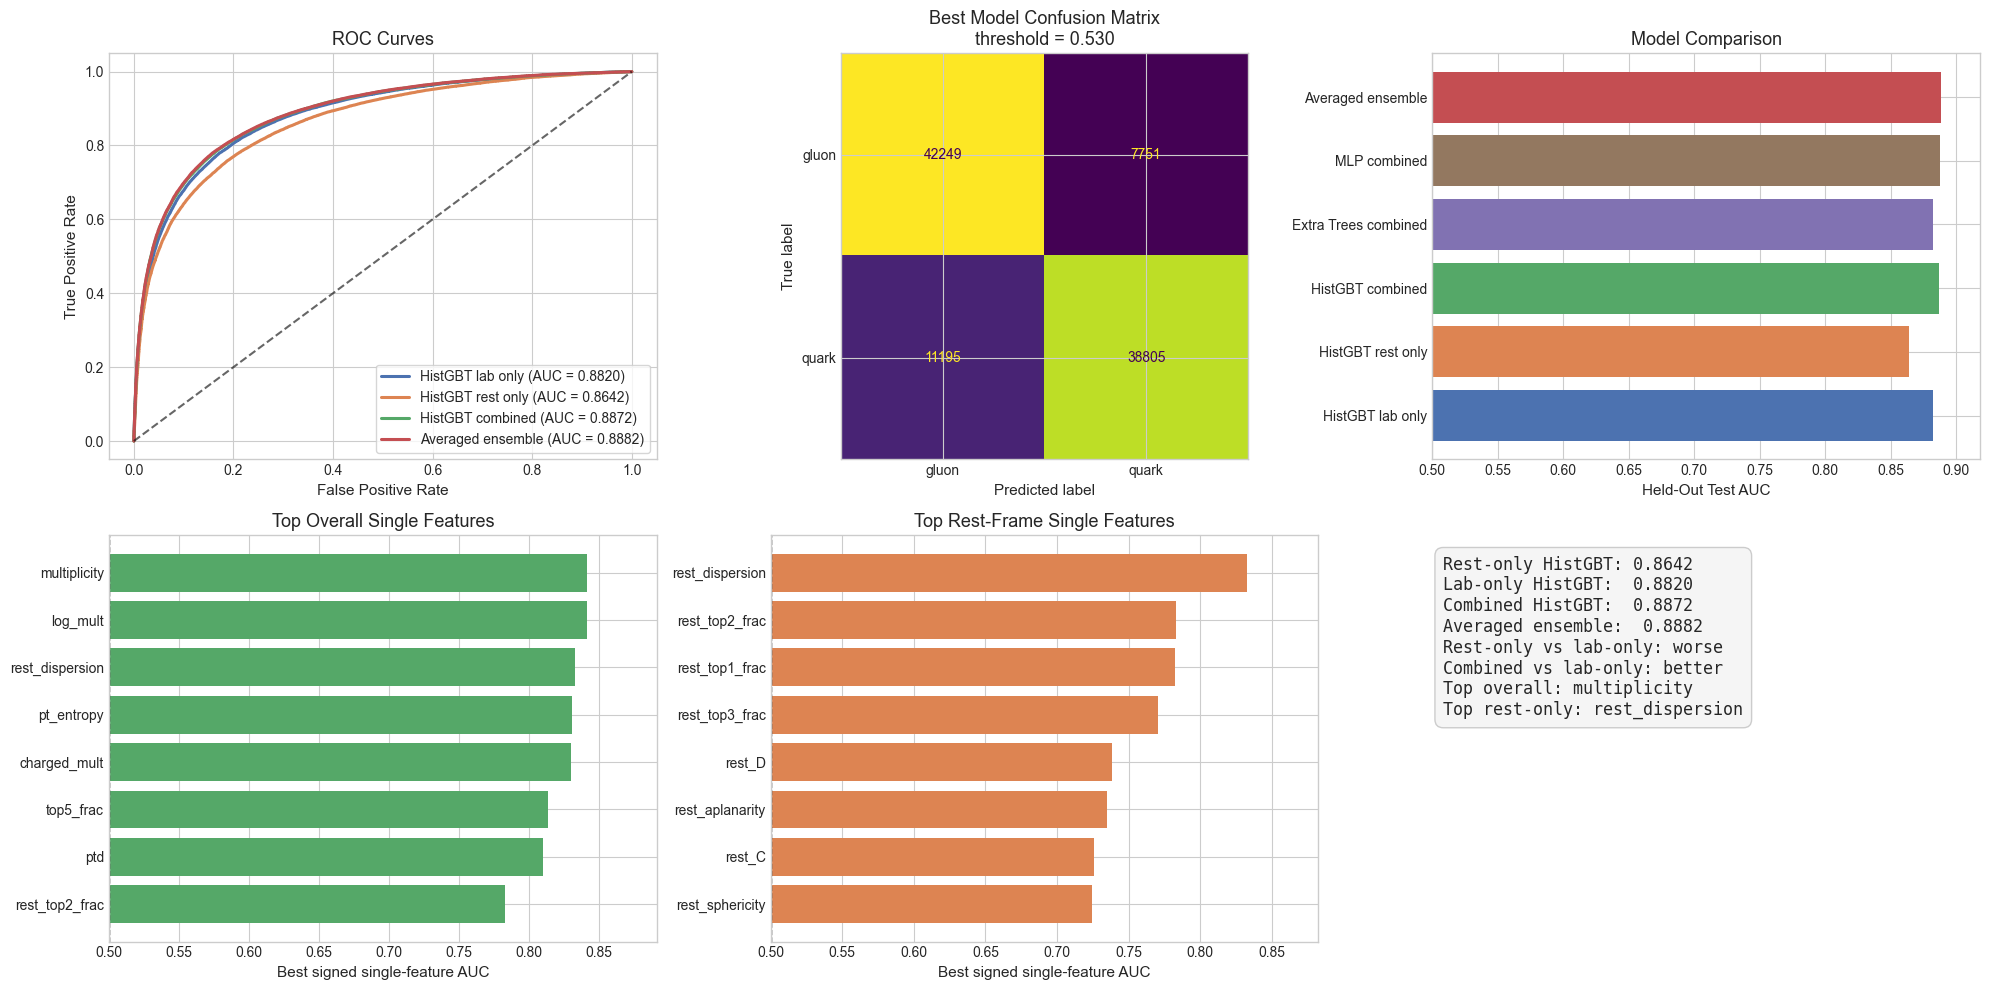

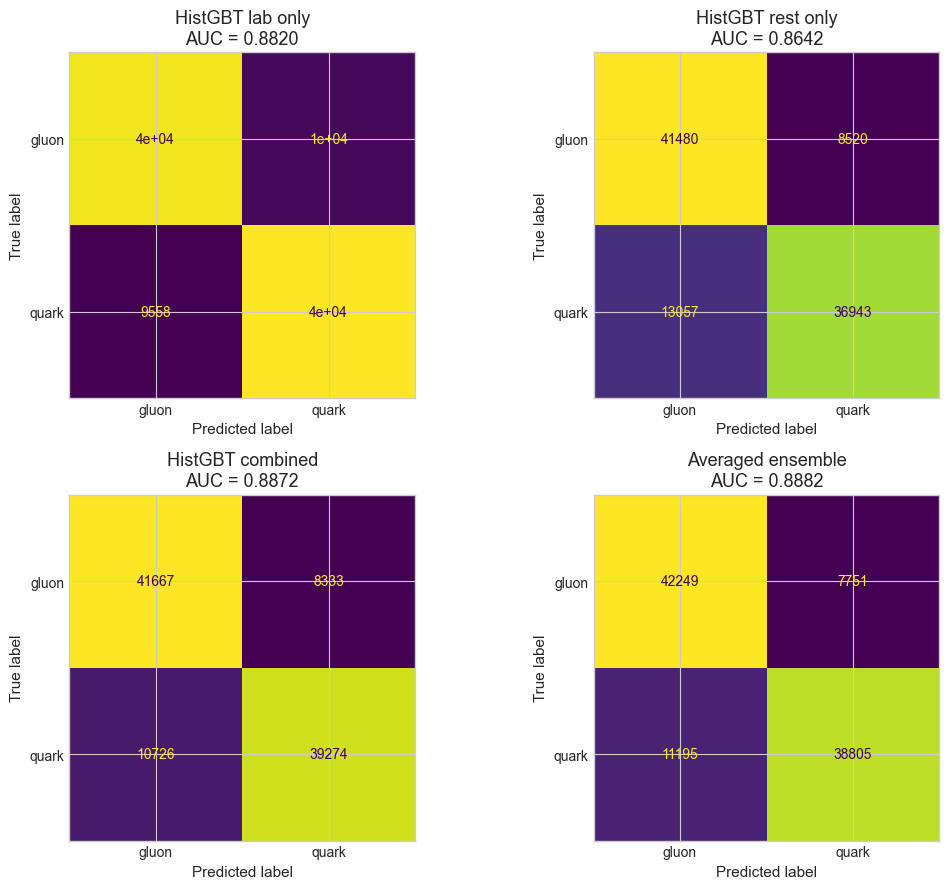

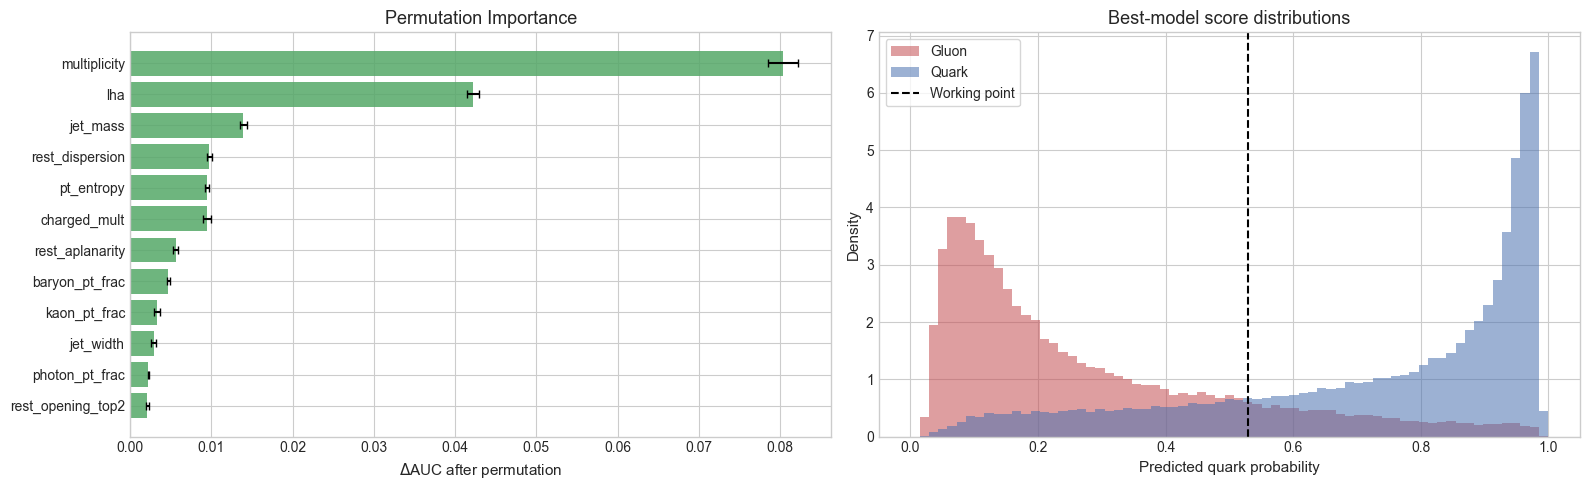

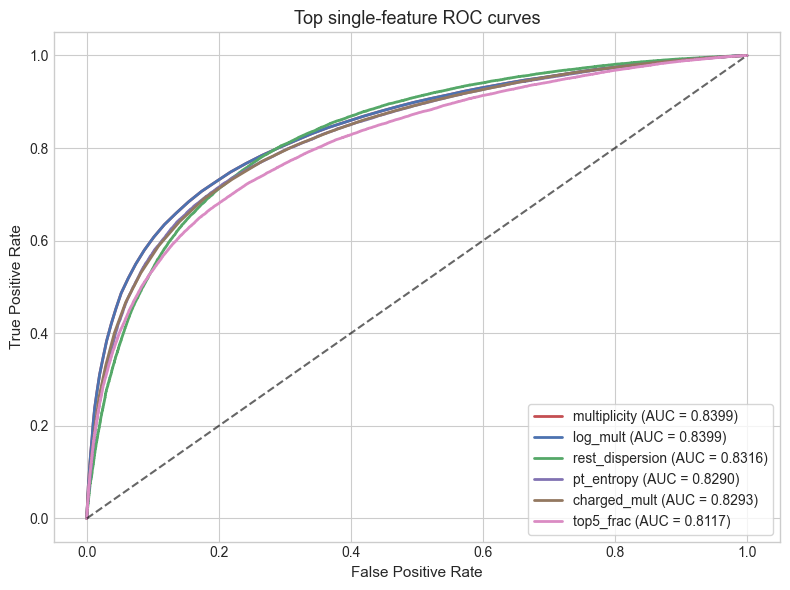

In [11]:
lab_metrics = classification["lab_metrics"]
rest_metrics = classification["rest_metrics"]
combined_hist_metrics = classification["combined_hist_metrics"]
ensemble_metrics = classification["ensemble_metrics"]
overall_rankings = classification["overall_rankings"]
rest_rankings = classification["rest_rankings"]
rest_specific_rankings = classification["rest_specific_rankings"]
model_results = classification["model_results"]
combined_features = classification["combined_features"]
labels = classification["labels"]
test_idx = classification["test_idx"]

ordered_models = [
    "HistGBT lab only",
    "HistGBT rest only",
    "HistGBT combined",
    "Extra Trees combined",
    "MLP combined",
    "Averaged ensemble",
]

print("Model comparison on the 5-file sample:")
for name in ordered_models:
    metrics = model_results[name]
    print(
        f"  {name:22s} AUC = {metrics['auc']:.4f} | "
        f"balanced acc = {metrics['test_balanced_accuracy']:.4f}"
    )

print(f"\nRest-only compared with lab-only: {classification['rest_vs_lab']}")
print(f"Combined compared with lab-only: {classification['combined_vs_lab']}")
print(
    f"Best overall model: {classification['best_model_name']} "
    f"(AUC = {classification['best_model_metrics']['auc']:.4f})"
)
print(
    f"Strongest overall single feature: {overall_rankings[0][0]} "
    f"(score = {overall_rankings[0][1]:.4f})"
)
print(
    f"Strongest genuinely rest-frame feature: {rest_specific_rankings[0][0]} "
    f"(score = {rest_specific_rankings[0][1]:.4f})"
)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for name, metrics, color in [
    ("HistGBT lab only", lab_metrics, "#4c72b0"),
    ("HistGBT rest only", rest_metrics, "#dd8452"),
    ("HistGBT combined", combined_hist_metrics, "#55a868"),
    ("Averaged ensemble", ensemble_metrics, "#c44e52"),
]:
    axes[0, 0].plot(metrics["fpr"], metrics["tpr"], lw=2.2, color=color, label=f"{name} (AUC = {metrics['auc']:.4f})")
axes[0, 0].plot([0, 1], [0, 1], "--", color="black", alpha=0.6)
axes[0, 0].set_title("ROC Curves")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].legend(loc="lower right")

ConfusionMatrixDisplay(
    ensemble_metrics["confusion_matrix"],
    display_labels=["gluon", "quark"],
).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title(f"Best Model Confusion Matrix\nthreshold = {ensemble_metrics['threshold']:.3f}")

model_aucs = [model_results[name]["auc"] for name in ordered_models]
axes[0, 2].barh(ordered_models, model_aucs, color=["#4c72b0", "#dd8452", "#55a868", "#8172b2", "#937860", "#c44e52"])
axes[0, 2].set_xlim(0.5, max(model_aucs) + 0.03)
axes[0, 2].set_title("Model Comparison")
axes[0, 2].set_xlabel("Held-Out Test AUC")

top_overall = overall_rankings[:8]
axes[1, 0].barh(
    [name for name, _ in top_overall][::-1],
    [score for _, score in top_overall][::-1],
    color="#55a868",
)
axes[1, 0].axvline(0.5, color="black", ls="--", lw=1)
axes[1, 0].set_xlim(0.5, max(score for _, score in top_overall) + 0.05)
axes[1, 0].set_title("Top Overall Single Features")
axes[1, 0].set_xlabel("Best signed single-feature AUC")

top_rest = rest_specific_rankings[:8]
axes[1, 1].barh(
    [name for name, _ in top_rest][::-1],
    [score for _, score in top_rest][::-1],
    color="#dd8452",
)
axes[1, 1].axvline(0.5, color="black", ls="--", lw=1)
axes[1, 1].set_xlim(0.5, max(score for _, score in top_rest) + 0.05)
axes[1, 1].set_title("Top Rest-Frame Single Features")
axes[1, 1].set_xlabel("Best signed single-feature AUC")

axes[1, 2].axis("off")
summary_text = (
    f"Rest-only HistGBT: {rest_metrics['auc']:.4f}\n"
    f"Lab-only HistGBT:  {lab_metrics['auc']:.4f}\n"
    f"Combined HistGBT:  {combined_hist_metrics['auc']:.4f}\n"
    f"Averaged ensemble:  {ensemble_metrics['auc']:.4f}\n"
    f"Rest-only vs lab-only: {classification['rest_vs_lab']}\n"
    f"Combined vs lab-only: {classification['combined_vs_lab']}\n"
    f"Top overall: {overall_rankings[0][0]}\n"
    f"Top rest-only: {rest_specific_rankings[0][0]}"
)
axes[1, 2].text(
    0.02,
    0.95,
    summary_text,
    va="top",
    ha="left",
    fontsize=12,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor="#cccccc"),
)

plt.tight_layout()
plt.show()

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(
    axes_cm.flatten(),
    ["HistGBT lab only", "HistGBT rest only", "HistGBT combined", "Averaged ensemble"],
):
    metrics = model_results[name]
    ConfusionMatrixDisplay(
        metrics["confusion_matrix"],
        display_labels=["gluon", "quark"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAUC = {metrics['auc']:.4f}")

plt.tight_layout()
plt.show()

rng = np.random.default_rng(RANDOM_SEED + 17)
importance_idx_parts = []
for label_value in np.unique(labels):
    label_idx = test_idx[labels[test_idx] == label_value]
    take = min(10_000, len(label_idx))
    importance_idx_parts.append(rng.choice(label_idx, size=take, replace=False))
importance_idx = np.concatenate(importance_idx_parts)
rng.shuffle(importance_idx)

perm = permutation_importance(
    combined_hist_metrics["model"],
    combined_features[importance_idx],
    labels[importance_idx],
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_SEED,
    n_jobs=1,
)
top_perm_idx = np.argsort(perm.importances_mean)[-12:]

fig_diag, axes_diag = plt.subplots(1, 2, figsize=(16, 5))
axes_diag[0].barh(
    np.array(classification["combined_feature_names"])[top_perm_idx],
    perm.importances_mean[top_perm_idx],
    xerr=perm.importances_std[top_perm_idx],
    color="#55a868",
    alpha=0.85,
    capsize=3,
)
axes_diag[0].set_title("Permutation Importance")
axes_diag[0].set_xlabel(r"$\Delta$AUC after permutation")

for label_value, label_name, color in [
    (0, "Gluon", "#c44e52"),
    (1, "Quark", "#4c72b0"),
]:
    axes_diag[1].hist(
        ensemble_metrics["test_scores"][labels[test_idx] == label_value],
        bins=np.linspace(0, 1, 70),
        density=True,
        alpha=0.55,
        color=color,
        label=label_name,
    )
axes_diag[1].axvline(ensemble_metrics["threshold"], color="black", ls="--", lw=1.5, label="Working point")
axes_diag[1].set_title("Best-model score distributions")
axes_diag[1].set_xlabel("Predicted quark probability")
axes_diag[1].set_ylabel("Density")
axes_diag[1].legend()

plt.tight_layout()
plt.show()

top_single = overall_rankings[:6]
fig_single, ax_single = plt.subplots(figsize=(8, 6))
for name, color in zip(
    [name for name, _ in top_single],
    ["#c44e52", "#4c72b0", "#55a868", "#8172b2", "#937860", "#da8bc3"],
):
    column = classification["combined_feature_names"].index(name)
    values = combined_features[test_idx, column]
    fpr, tpr, _ = roc_curve(labels[test_idx], values)
    auc = roc_auc_score(labels[test_idx], values)
    if auc < 0.5:
        fpr, tpr, _ = roc_curve(labels[test_idx], -values)
        auc = roc_auc_score(labels[test_idx], -values)
    ax_single.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {auc:.4f})")
ax_single.plot([0, 1], [0, 1], "--", color="black", alpha=0.6)
ax_single.set_title("Top single-feature ROC curves")
ax_single.set_xlabel("False Positive Rate")
ax_single.set_ylabel("True Positive Rate")
ax_single.legend(loc="lower right")

plt.tight_layout()
plt.show()

The classifier results answer the rest-frame question pretty clearly. Using only the rest-frame block gives a weaker score than the enriched lab-only block, which suggests that the lab features keep more direct information about the radiation profile and the particle content of the jet. At the same time, the rest-frame variables are clearly not redundant: once they are added on top of the lab features, the AUC increases. So the rest frame works better here as an additional source of shape information than as a replacement for the lab frame. The gain is not huge, but it is consistent. Among the genuinely rest-frame variables, `rest_dispersion` stands out the most. One possible reason the rest-frame block scores a bit lower on its own is that it may be less tied to this narrow lab-frame kinematic window and therefore capture more kinematic-independent structure, which also helps explain why combining it with the richer lab features works better.

## References

1. P. Komiske, E. Metodiev, J. Thaler, *Energy Flow Networks: Deep Sets for Particle Jets*, JHEP 01 (2019) 121, arXiv:1810.05165.
2. Zenodo dataset record: *Pythia 8 Quark and Gluon Jets for Energy Flow*, DOI: 10.5281/zenodo.3164691.
3. ATLAS Collaboration, *Performance and efficiency of a transformer-based quark/gluon jet tagger in the ATLAS experiment*, arXiv:2512.03949.
4. S. Vent, R. Winterhalder, T. Plehn, *How to Deep-Learn the Theory behind Quark-Gluon Tagging*, arXiv:2507.21214.
5. D. Kim et al., *Comparison of Image Processing Models in Quark Gluon Jet Classification*, arXiv:2602.00141.


## Thank you!
Please mail me at sreenandan.shashidharan@gmail.com or at 24JE0701@iitism.ac.in if anything is amiss. I sincerely apologise in advance. 